# Clustering jerárquico

> Cómo agrupar datos sin etiquetas construyendo una jerarquía de grupos: el dendrograma, los criterios de enlace (simple, completo, medio, Ward), cómo elegir el número de grupos y qué distancia usar según el tipo de datos.
>
> **Requisitos previos:** [Distancias y similitud](../03-preparacion-datos/05-distancias-y-similitud.ipynb), [Transformación de datos](../03-preparacion-datos/03-transformacion-datos.ipynb) (escalado) · **Relacionado:** [k-means y derivados](05-kmeans-y-derivados.ipynb), [Clustering por densidad](06-clustering-densidad.ipynb)

## 1. Idea clave

El **clustering jerárquico** (*hierarchical clustering*) agrupa observaciones sin etiquetas construyendo una **jerarquía** completa de grupos, en lugar de una única partición. Hay dos estrategias:

- **Aglomerativa** (AHC, *bottom-up*): cada observación empieza siendo su propio grupo, y en cada paso se fusionan los dos grupos más cercanos, hasta que solo queda uno. Es la más usada.
- **Divisiva** (*top-down*): todo empieza en un grupo, que se divide recursivamente.

El resultado se representa con un **dendrograma**, un árbol que muestra qué se fusiona con qué y a qué distancia. Cortándolo a distintas alturas se obtienen agrupaciones con más o menos grupos, **sin tener que fijar su número de antemano**.

Su comportamiento depende de dos decisiones: la **distancia** entre observaciones y el **criterio de enlace** (*linkage*), que define la distancia entre grupos. Con enlace simple encuentra grupos alargados o con formas raras; con Ward, grupos compactos y de tamaño parecido. Es muy interpretable, pero caro: necesita todas las distancias entre pares de puntos, así que no escala a cientos de miles de observaciones.

## 2. Conceptos importantes

### 2.1. El algoritmo aglomerativo

1. Cada una de las $n$ observaciones es un grupo.
2. Calcular la distancia entre todos los pares de grupos.
3. Fusionar los dos grupos más cercanos.
4. Repetir 2–3 hasta que quede un solo grupo ($n - 1$ fusiones).

Es un algoritmo **voraz** (*greedy*): cada fusión es la mejor en ese momento y no se deshace nunca, así que no garantiza el agrupamiento globalmente óptimo.

### 2.2. Criterios de enlace

Para dos grupos $A$ y $B$, con $d(a, b)$ la distancia entre dos observaciones:

| Enlace | Distancia entre grupos | Tiende a formar | Punto débil |
|---|---|---|---|
| **Simple** (*single*) | $\min_{a \in A,\, b \in B} d(a, b)$ | Grupos alargados, de cualquier forma | **Efecto cadena**: unos pocos puntos intermedios unen grupos distintos; muy sensible al ruido |
| **Completo** (*complete*) | $\max_{a \in A,\, b \in B} d(a, b)$ | Grupos compactos, de diámetro parecido | Sensible a los atípicos |
| **Medio** (*average*, UPGMA) | $\frac{1}{\lvert A\rvert\lvert B\rvert}\sum_{a \in A}\sum_{b \in B} d(a, b)$ | Compromiso entre simple y completo | Puede aislar atípicos en grupos diminutos |
| **Centroide** | $d(\bar{\mathbf{a}}, \bar{\mathbf{b}})$, distancia entre centroides | Grupos compactos | Solo con distancia euclídea; la altura de fusión puede **bajar** (inversiones) |
| **Ward** | Aumento de la suma de cuadrados dentro de los grupos al fusionar $A$ y $B$ | Grupos esféricos de tamaño similar (como k-means) | Solo con distancia **euclídea** |

donde $\lvert A\rvert$ es el número de observaciones de $A$ y $\bar{\mathbf{a}}$ su centroide (el punto medio del grupo). El criterio de Ward, en concreto, fusiona en cada paso los dos grupos cuya unión aumenta menos

$$
\Delta(A, B) = \frac{\lvert A\rvert\,\lvert B\rvert}{\lvert A\rvert + \lvert B\rvert}\,\lVert \bar{\mathbf{a}} - \bar{\mathbf{b}} \rVert^2
$$

la suma de cuadrados dentro de los grupos (la *inercia* que minimiza k-means).

### 2.3. El dendrograma

- Cada **hoja** es una observación. Cada **unión** es una fusión, dibujada a la **altura** de la distancia entre los grupos fusionados.
- **Cortar** el dendrograma con una línea horizontal da una partición: cada rama que cruza la línea es un grupo.
- Un **salto grande** entre alturas de fusión consecutivas indica que se están uniendo grupos muy distintos. Cortar justo antes de ese salto es un criterio habitual para elegir el número de grupos.
- Las alturas solo son comparables **dentro del mismo método**: con Ward son aumentos de varianza, con enlace simple distancias mínimas. Comparar alturas entre métodos no tiene sentido.
- El orden horizontal de las hojas es en parte arbitrario: dos hojas vecinas no tienen por qué ser parecidas si se unen muy arriba.

La **correlación cofenética** mide lo fiel que es el dendrograma a las distancias originales: la distancia *cofenética* entre dos observaciones es la altura a la que se unen por primera vez, y se correlaciona con su distancia real. Cercana a 1 significa que el árbol conserva bien las distancias. Pero **no** garantiza que los grupos sean útiles.

### 2.4. Coste

Hay que almacenar las $\frac{n(n-1)}{2}$ distancias entre pares: con $n = 50.000$ son unos 1.250 millones de valores (≈ 10 GB en doble precisión). El tiempo crece entre $O(n^2)$ y $O(n^3)$ según el enlace. Para conjuntos grandes se usa una muestra, restricciones de conectividad (solo se fusionan vecinos) o métodos particionales como [k-means](05-kmeans-y-derivados.ipynb).

## 3. Código

Usamos conjuntos sintéticos de scikit-learn con formas conocidas (grupos esféricos, lunas y círculos concéntricos) para ver cómo se comporta cada enlace, y el conjunto real **wine** (178 vinos de 3 variedades, 13 medidas químicas; procede del repositorio UCI) para el dendrograma. Las variedades **no** se usan para agrupar; solo sirven para comprobar después si los grupos encontrados tienen sentido, con el **índice de Rand ajustado** (ARI, *adjusted Rand index*): 1 = coincidencia perfecta, ≈ 0 = como al azar.

### 3.1. Cómo se comporta cada criterio de enlace

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering, BisectingKMeans
from sklearn.datasets import load_wine, make_blobs, make_circles, make_moons
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

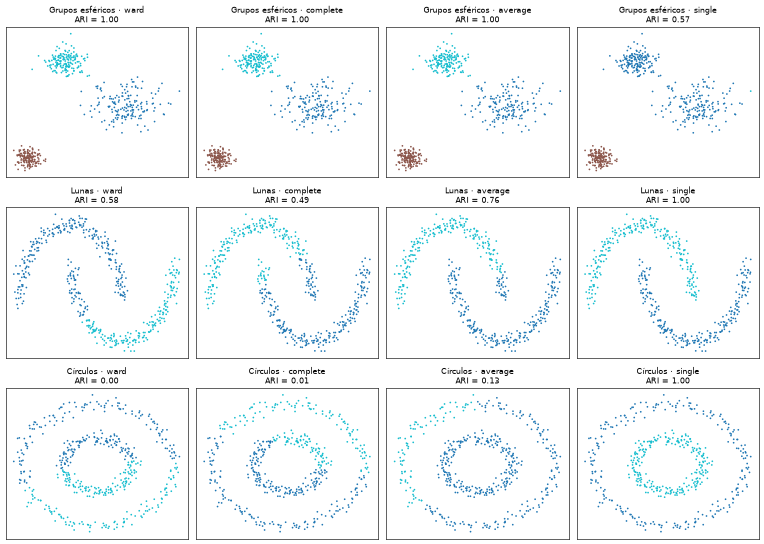

,ward,complete,average,single
Grupos esféricos,1.00,1.00,1.00,0.57
Lunas,0.58,0.49,0.76,1.00
Círculos,0.00,0.01,0.13,1.00


In [2]:
conjuntos = {
    "Grupos esféricos": make_blobs(n_samples=500, centers=3, cluster_std=[1.2, 2.0, 0.8], random_state=42),
    "Lunas": make_moons(n_samples=500, noise=0.06, random_state=42),
    "Círculos": make_circles(n_samples=500, factor=0.45, noise=0.05, random_state=42),
}
enlaces = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(3, 4, figsize=(14, 10), dpi=55)
ari = {}
for fila, (nombre, (X_sint, y_sint)) in enumerate(conjuntos.items()):
    X_sint = StandardScaler().fit_transform(X_sint)
    k = len(np.unique(y_sint))
    for col, enlace in enumerate(enlaces):
        etiquetas = AgglomerativeClustering(n_clusters=k, linkage=enlace).fit_predict(X_sint)
        ari[(nombre, enlace)] = adjusted_rand_score(y_sint, etiquetas)
        ax = axes[fila, col]
        ax.scatter(X_sint[:, 0], X_sint[:, 1], c=etiquetas, cmap="tab10", s=5, linewidths=0)
        ax.set_title(f"{nombre} · {enlace}\nARI = {ari[(nombre, enlace)]:.2f}", fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout()
plt.show()

pd.Series(ari).unstack().loc[list(conjuntos), enlaces].round(2)

- En los **grupos esféricos**, Ward, el completo y el medio aciertan por completo. El **enlace simple falla** (ARI 0,57): los puntos del grupo más disperso forman una cadena que lo une con otro.
- En las **lunas** y los **círculos** ocurre justo lo contrario: solo el **enlace simple** los separa bien. Precisamente el efecto cadena le permite seguir una forma alargada o curva punto a punto. Los demás enlaces buscan grupos compactos y cortan las formas por la mitad.

No hay un enlace mejor en general: depende de la **forma** que se espera de los grupos.

### 3.2. El dendrograma en datos reales

En *wine* las variables tienen escalas muy distintas, así que primero estandarizamos (ver [distancias y escalado](../03-preparacion-datos/05-distancias-y-similitud.ipynb)). Construimos la jerarquía con Ward y dibujamos solo las últimas 25 fusiones (`truncate_mode="lastp"`), porque un árbol con 178 hojas es ilegible:

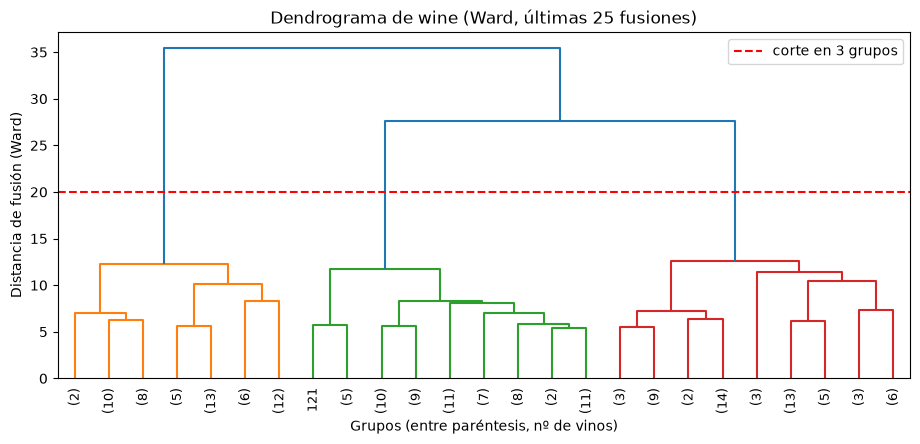

Alturas de las 6 últimas fusiones: [11.4 11.7 12.2 12.6 27.7 35.4]


In [3]:
X_wine, y_wine = load_wine(return_X_y=True)
X_wine = StandardScaler().fit_transform(X_wine)

Z = linkage(X_wine, method="ward")  # matriz de enlace: una fila por fusión

fig, ax = plt.subplots(figsize=(11, 4.5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, leaf_font_size=9,
           show_leaf_counts=True, ax=ax)
ax.axhline(20, color="red", linestyle="--", label="corte en 3 grupos")
ax.set_title("Dendrograma de wine (Ward, últimas 25 fusiones)")
ax.set_xlabel("Grupos (entre paréntesis, nº de vinos)")
ax.set_ylabel("Distancia de fusión (Ward)")
ax.legend()
plt.show()

print("Alturas de las 6 últimas fusiones:", Z[-6:, 2].round(1))

Las últimas fusiones ocurren a alturas de 27,7 y 35,4, muy por encima de las anteriores (12,6 o menos). Ese **salto** indica que las dos últimas fusiones unen grupos muy distintos: cortar justo antes (línea roja) da **3 grupos**. `fcluster` hace el corte:

In [4]:
grupos = fcluster(Z, t=3, criterion="maxclust")  # etiquetas 1..3 (SciPy empieza en 1)
print(f"Tamaños de los grupos: {np.bincount(grupos)[1:]}")
print(f"ARI frente a las variedades reales: {adjusted_rand_score(y_wine, grupos):.2f}")
pd.crosstab(pd.Series(y_wine, name="variedad"), pd.Series(grupos, name="grupo"))

Tamaños de los grupos: [56 64 58]
ARI frente a las variedades reales: 0.79


grupo,1,2,3
variedad,,,
0,0,59,0
1,8,5,58
2,48,0,0


Sin haber visto las etiquetas, los 3 grupos coinciden en gran medida con las 3 variedades de vino (ARI 0,79). La tabla muestra qué vinos quedan mal agrupados.

### 3.3. Elegir el número de grupos

Además del salto en el dendrograma, se puede usar el **coeficiente de silueta** (*silhouette*), que compara, para cada punto, la distancia media a su propio grupo con la distancia al grupo vecino más cercano. Va de −1 a 1, y cuanto más alto, mejor separados están los grupos (se verá con detalle en [clustering por densidad](06-clustering-densidad.ipynb)):

In [5]:
pd.Series({k: silhouette_score(X_wine, fcluster(Z, t=k, criterion="maxclust")) for k in range(2, 7)},
          name="silueta").rename_axis("nº de grupos").round(3).to_frame()

,silueta
nº de grupos,
2,0.267
3,0.277
4,0.226
5,0.187
6,0.180


La silueta es máxima con 3 grupos, en coherencia con el dendrograma. Valores en torno a 0,28 indican grupos reales pero con bastante solapamiento. Es lo habitual en datos reales, muy lejos de los grupos perfectamente separados de los ejemplos sintéticos.

### 3.4. Fidelidad del dendrograma frente a calidad de los grupos

Comparamos los cuatro enlaces en *wine* con dos criterios distintos: la correlación cofenética (¿conserva el árbol las distancias?) y el ARI al cortar en 3 grupos (¿son útiles los grupos?):

In [6]:
distancias = pdist(X_wine)
filas = {}
for enlace in enlaces:
    Z_enlace = linkage(X_wine, method=enlace)
    corte = fcluster(Z_enlace, t=3, criterion="maxclust")
    filas[enlace] = {
        "correlación cofenética": round(cophenet(Z_enlace, distancias)[0], 3),
        "ARI (3 grupos)": round(adjusted_rand_score(y_wine, corte), 3),
        "tamaños": np.bincount(corte)[1:].tolist(),
    }
pd.DataFrame(filas).T

,correlación cofenética,ARI (3 grupos),tamaños
ward,0.662,0.79,"[56, 64, 58]"
complete,0.592,0.577,"[69, 51, 58]"
average,0.759,-0.005,"[3, 174, 1]"
single,0.544,-0.007,"[3, 174, 1]"


- El enlace **medio** tiene la correlación cofenética más alta: su árbol es el más fiel a las distancias. Pero al cortarlo en 3 grupos da una partición **inútil**: un grupo con casi todos los vinos y dos grupos diminutos con los atípicos (ARI ≈ 0). Lo mismo ocurre con el enlace simple.
- **Ward** tiene una cofenética menor, pero produce grupos equilibrados y con sentido (ARI 0,79).

Una buena correlación cofenética dice que el dendrograma resume bien las distancias, no que sus cortes den grupos útiles.

### 3.5. Datos binarios: distancia de Jaccard

Para variables de presencia/ausencia, como los ingredientes de una receta, la distancia adecuada es la de [Jaccard](../03-preparacion-datos/05-distancias-y-similitud.ipynb), que solo mira los ingredientes presentes. Ward no se puede usar con ella, así que usamos el enlace medio. Con un conjunto pequeño, el dendrograma completo con nombres es legible:

(10, 21)


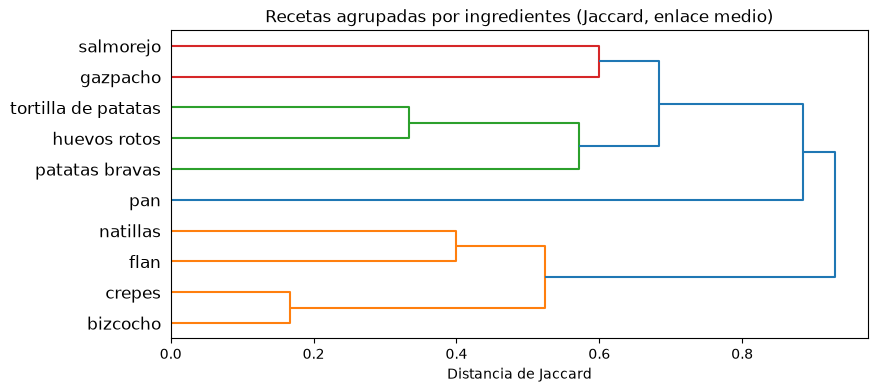

In [7]:
recetas = {
    "tortilla de patatas": ["huevo", "patata", "cebolla", "aceite", "sal"],
    "huevos rotos": ["huevo", "patata", "aceite", "sal", "jamón"],
    "patatas bravas": ["patata", "aceite", "sal", "tomate", "pimentón"],
    "gazpacho": ["tomate", "pepino", "pimiento", "ajo", "aceite", "sal", "vinagre"],
    "salmorejo": ["tomate", "pan", "ajo", "aceite", "sal", "huevo", "jamón"],
    "bizcocho": ["harina", "huevo", "azúcar", "leche", "mantequilla", "levadura"],
    "flan": ["huevo", "azúcar", "leche"],
    "natillas": ["leche", "huevo", "azúcar", "canela", "maicena"],
    "crepes": ["harina", "huevo", "leche", "azúcar", "mantequilla"],
    "pan": ["harina", "agua", "sal", "levadura"],
}
# Matriz binaria: una fila por receta, una columna por ingrediente
ingredientes = pd.Series(recetas).explode().str.get_dummies().groupby(level=0).max().astype(bool)
print(ingredientes.shape)

Z_recetas = linkage(pdist(ingredientes.to_numpy(), metric="jaccard"), method="average")
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z_recetas, labels=ingredientes.index.tolist(), orientation="right", ax=ax)
ax.set_title("Recetas agrupadas por ingredientes (Jaccard, enlace medio)")
ax.set_xlabel("Distancia de Jaccard")
plt.show()

El dendrograma separa los **postres** (flan, natillas, crepes, bizcocho) de los **platos salados**, y dentro de estos agrupa los de patata y los de tomate. El pan, que comparte harina y levadura con el bizcocho pero sal con los platos salados, se une tarde a todos: no se parece claramente a ninguno.

### 3.6. Estrategia divisiva: `BisectingKMeans`

scikit-learn no incluye un clustering divisivo clásico, pero `BisectingKMeans` sigue esa idea: parte de un grupo y divide repetidamente uno de ellos en dos con k-means:

In [8]:
divisivo = BisectingKMeans(n_clusters=3, random_state=42).fit_predict(X_wine)
print(f"BisectingKMeans, ARI frente a las variedades: {adjusted_rand_score(y_wine, divisivo):.2f}")

BisectingKMeans, ARI frente a las variedades: 0.69


Obtiene un resultado parecido al de Ward (ARI 0,69 frente a 0,79), a un coste mucho menor, porque no necesita la matriz de distancias completa.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Función / clase | Parámetro | Qué controla | Consejo |
|---|---|---|---|
| `scipy...linkage` | `method` | Criterio de enlace | `"ward"`, `"complete"`, `"average"`, `"single"`… |
| | `metric` | Distancia entre observaciones | `"ward"`, `"centroid"` y `"median"` solo con `"euclidean"` |
| | `optimal_ordering` | Reordenar las hojas para que las vecinas sean parecidas | Dendrogramas más legibles, con algo más de coste |
| `scipy...fcluster` | `criterion`, `t` | Cómo se corta: `"maxclust"` (nº de grupos) o `"distance"` (altura) | Las etiquetas empiezan en **1**, no en 0 |
| `scipy...dendrogram` | `truncate_mode`, `p` | Mostrar solo las últimas `p` fusiones | Imprescindible con más de unas decenas de puntos |
| `AgglomerativeClustering` | `n_clusters` / `distance_threshold` | Número de grupos o altura de corte | Uno de los dos debe ser `None` |
| | `linkage`, `metric` | Enlace y distancia | Con `linkage="ward"`, `metric` debe ser euclídea |
| | `connectivity` | Qué puntos pueden fusionarse | Un grafo de vecinos (`kneighbors_graph`) acelera y respeta la estructura local |

### 4.2. Errores comunes

Varias de estas lecciones salen de un análisis real que comparó los criterios de enlace sobre conjuntos sintéticos (grupos esféricos, lunas y círculos) y agrupó recetas de cocina a partir de *embeddings* de texto y de una matriz binaria de ingredientes.

**1. Elegir el enlace sin pensar en la forma de los grupos.** En aquel análisis, Ward fue el mejor con grupos esféricos, y el enlace simple fue el único que separó las lunas y los círculos (3.1). No hay un criterio mejor en general. Si los grupos pueden tener formas alargadas o curvas, prueba el enlace simple o los [métodos por densidad](06-clustering-densidad.ipynb). Si se esperan grupos compactos, Ward o el completo.

**2. Confiar en el enlace simple con datos ruidosos.** El efecto cadena que le permite seguir las lunas es también su debilidad: basta con unos pocos puntos de ruido entre los grupos para que los una. Añadimos 25 puntos al azar a las lunas:

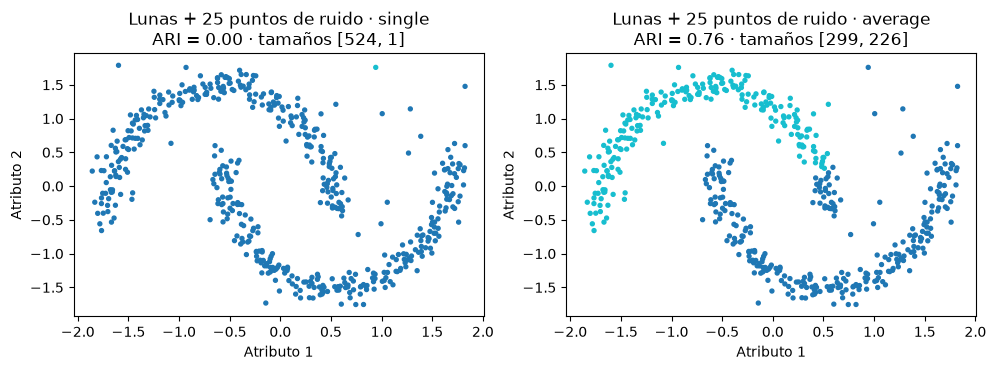

In [9]:
rng = np.random.default_rng(42)
X_lunas, y_lunas = make_moons(n_samples=500, noise=0.06, random_state=42)
ruido = rng.uniform([-1.2, -0.7], [2.2, 1.2], size=(25, 2))
X_lunas_ruido = StandardScaler().fit_transform(np.vstack([X_lunas, ruido]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, enlace in zip(axes, ["single", "average"]):
    etiquetas = AgglomerativeClustering(n_clusters=2, linkage=enlace).fit_predict(X_lunas_ruido)
    valor_ari = adjusted_rand_score(y_lunas, etiquetas[:500])  # ARI solo sobre los puntos originales
    ax.scatter(X_lunas_ruido[:, 0], X_lunas_ruido[:, 1], c=etiquetas, cmap="tab10", s=8)
    ax.set_title(f"Lunas + 25 puntos de ruido · {enlace}\nARI = {valor_ari:.2f} · tamaños {np.bincount(etiquetas).tolist()}")
    ax.set_xlabel("Atributo 1")
    ax.set_ylabel("Atributo 2")
plt.tight_layout()
plt.show()

Con solo 25 puntos de ruido (un 5 %), el enlace simple pasa de separar perfectamente las lunas a meter todo en un grupo y dejar el otro con un único punto aislado (ARI 0). El enlace medio aguanta mucho mejor (ARI 0,76), aunque tampoco separa limpiamente las dos lunas.

**3. Leer un dendrograma "limpio" como prueba de buenos grupos.** En las lunas, el enlace completo produjo un dendrograma con dos ramas altas y claramente separadas, pero en el gráfico de puntos cada grupo mezclaba las dos lunas. El dendrograma solo muestra cómo se fusionan los grupos **según el criterio elegido**. Comprueba siempre los grupos en los datos (gráficos, perfiles de cada grupo, métricas como la silueta) y no solo el árbol (ver también 3.4).

**4. Comparar alturas de fusión entre métodos distintos.** En ese mismo análisis se observó que con Ward "las alturas de fusión son mayores". Es cierto, pero no significa nada: con Ward la altura mide aumentos de varianza, y con el enlace simple distancias mínimas entre puntos. Las alturas solo sirven para comparar fusiones dentro del mismo dendrograma.

**5. Usar Ward (o el centroide) con distancias no euclídeas.** Ward minimiza varianzas, que solo tienen sentido con distancia euclídea. Para los ingredientes binarios se eligió correctamente la distancia de Jaccard, y con ella hay que usar enlace medio, completo o simple (3.5). SciPy da error si se pide Ward con otra distancia:

In [10]:
try:
    linkage(X_wine, method="ward", metric="cityblock")
except ValueError as error:
    print(f"ValueError: {error}")

ValueError: `method=ward` requires the distance metric to be Euclidean


**6. No escalar las variables.** Como cualquier método basado en distancias, el resultado depende de las escalas: sin estandarizar, las variables con valores grandes dominan la distancia y, con ella, toda la jerarquía (ver [distancias y similitud](../03-preparacion-datos/05-distancias-y-similitud.ipynb)).

**7. Aplicarlo a conjuntos grandes sin pensar en el coste.** La matriz de distancias crece con el cuadrado de $n$. Con decenas de miles de observaciones (por ejemplo, miles de *embeddings* de texto), trabaja con una muestra, usa `connectivity` en `AgglomerativeClustering` o cambia a un método particional.

## 5. Comparación con métodos relacionados

| Criterio | Jerárquico aglomerativo | [k-means](05-kmeans-y-derivados.ipynb) | [DBSCAN / HDBSCAN](06-clustering-densidad.ipynb) |
|---|---|---|---|
| Nº de grupos | Se elige después, cortando el dendrograma | Hay que fijarlo antes | Lo determina el algoritmo |
| Forma de los grupos | Depende del enlace: esférica (Ward) o arbitraria (simple) | Esférica, tamaños parecidos | Arbitraria |
| Ruido y atípicos | No los identifica; el enlace simple es muy sensible | Los asigna a algún grupo y desplazan centroides | Los marca como ruido |
| Distancias admitidas | Cualquiera (salvo Ward y centroide: euclídea) | Euclídea | Cualquiera |
| Coste | $O(n^2)$ memoria, $O(n^2)$–$O(n^3)$ tiempo | Casi lineal en $n$ | $O(n \log n)$ con índices espaciales |
| Asigna datos nuevos | No directamente | Sí (centroide más cercano) | No directamente (HDBSCAN aproximado) |
| Resultado extra | Jerarquía completa (dendrograma) | Centroides | Densidades, puntos de ruido |

| Enlace | Cuándo usarlo |
|---|---|
| Ward | Opción por defecto con variables numéricas escaladas y grupos compactos |
| Completo | Grupos compactos cuando no se puede usar Ward (distancias no euclídeas) |
| Medio | Distancias no euclídeas (coseno, Jaccard); compromiso general |
| Simple | Formas alargadas o curvas sin ruido; detectar atípicos (quedan aislados) |

## 6. Referencias

### Fuentes

- SciPy: [`scipy.cluster.hierarchy.linkage`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) (criterios de enlace y matriz de enlace), `dendrogram`, `fcluster` y `cophenet`.
- scikit-learn: [*Clustering*](https://scikit-learn.org/stable/modules/clustering.html) (`AgglomerativeClustering`, `BisectingKMeans`, índice de Rand ajustado, silueta).
- Datasets: [wine en scikit-learn](https://scikit-learn.org/stable/datasets/toy_dataset.html) (repositorio UCI) y generadores sintéticos `make_blobs`, `make_moons` y `make_circles`.

### Para saber más

- Kaufman, L. y Rousseeuw, P. J. (1990). *Finding Groups in Data: An Introduction to Cluster Analysis*. Wiley. Referencia clásica del análisis de conglomerados, incluidos los métodos jerárquicos y la silueta.
- Murtagh, F. y Contreras, P. (2012). *Algorithms for hierarchical clustering: an overview*. WIREs Data Mining and Knowledge Discovery, 2(1), 86–97. Revisión de los algoritmos jerárquicos y de sus implementaciones eficientes.